## Runge-Kutta Methods
1. [Runge–Kutta methods](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods)
2. [List of Runge–Kutta methods](https://en.wikipedia.org/wiki/List_of_Runge%E2%80%93Kutta_methods)
Butcher tableau for an **explicit** Runge-Kutta scheme 
\begin{array}
{c|ccccc}
0\\
c_2 & a_{21}\\
c_3 & a_{31} &a_{32} \\
\vdots & \vdots & & \ddots\\
c_s& a_{s1}& a_{s2} & \cdots & a_{s,s-1}\\
\hline
& b_1 &b_2 &\cdots & b_{s-1} & b_s \\ 
\end{array}
Then
$$
    y_{n+1} = y_n+h\sum_{i=1}^{s}b_i k_i
$$
where
\begin{align}
    k_1 &= f(t_n,y_n),\cr
    k_2 &= f(t_n+c_2h,y_n+h(a_{21}k_1)),\cr
    k_3 &= f(t_n+c_3h,y_n+h(a_{31}k_1+a_{32}k_2)),\cr
    &\vdots\cr
    k_s &= f(t_n+c_sh,y_n+h(a_{s1}k_1+a_{s2}k_2+\cdots+a_{s,s-1}k_{s-1}))\cr
\end{align}

### Van der Pol Oscillator
$$
        {d^2x\over dt^2}-{(1-x^2){dx\over dt}-x\over\varepsilon} = 0
$$
or as a system
\begin{align}
\dot x_1 & = x_2 \cr
\dot x_2 &= {(1-x_1^2)x_2-x_1\over\varepsilon}\cr
\end{align}
https://en.wikipedia.org/wiki/Van_der_Pol_oscillator

Notice that $(0,0)$ is the only fixed point and the Jacobian of the vector field is
$$
    J = \begin{bmatrix} 0 & 1\cr (-1 - 2 x_1 x_2)/\varepsilon & (1-x_1^2)/\varepsilon\cr\end{bmatrix}.
$$

If $(x_1,x_2)$ is a equilibrium point then $x_2=0$ from the first component.  Then $x_1=0$ as well.  That is $(0,0)$ is the only equilibrium point for this system.

In [76]:
import numpy as np, numpy.linalg as LA, math
from math import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicHermiteSpline

In [7]:
ε = 5e-1
J0 = np.array([[0,1],[-1/ε,1/ε]])
LA.eig(J0)[0]

array([1.+1.j, 1.-1.j])

In [5]:
def vanderpol(t,xx):
    x1,x2 = xx
    return [x2,((1-x1**2)*x2 - x1)/ε]

### Region of study
The restrictions
$$
    a\le x_1 \le b \quad c\le x_2 \le d
$$
define a rectangular region $R$.

Text(0.5, 1.0, 'Van der Pol vector field')

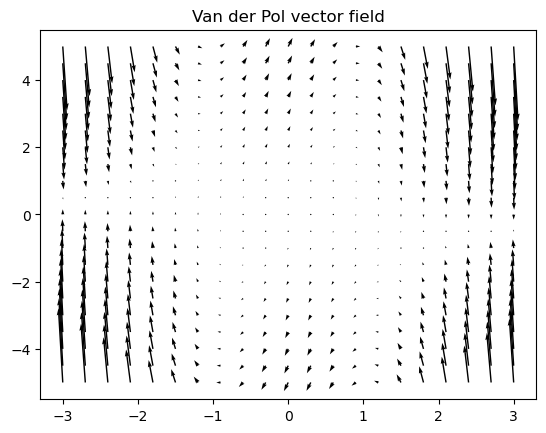

In [14]:
%matplotlib inline
a,b = -3.,3. # x1 limits
c,d = -5.,5. # x2 limits
npts  = 21
x1 = np.linspace(a,b,npts)
x2 = np.linspace(c,d,npts)
X1,X2 = np.meshgrid(x1,x2)
Z1,Z2 = vanderpol(_,(X1,X2))
plt.quiver(X1,X2,Z1,Z2)
plt.title('Van der Pol vector field')

In [63]:
t0,t1 = 0.,10.
Nsols = 10
#x10s = (b-a)*np.random.rand(Nsols)+a
#x20s = (c-d)*np.random.rand(Nsols)+d
#y0s = np.vstack((x10s,x20s)).T
y0s = [(1.9,0.),(2.1,0.0)]
t_span = [t0,t1]

tsteps = 2400
t_eval = np.linspace(t0,t1,tsteps+1)

In [64]:
%matplotlib notebook

292


<IPython.core.display.Javascript object>


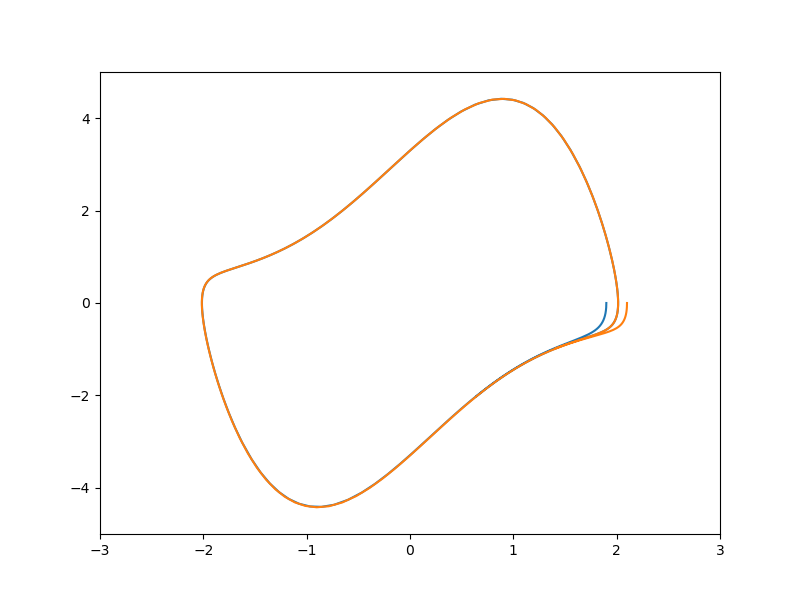

In [65]:
sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,atol=1e-8,rtol=1e-8))
maxsteps = max([len(sol.t) for sol in sols])
print(maxsteps)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,maxsteps+1),
                    init_func=init, blit=True)
plt.show()

148


<IPython.core.display.Javascript object>


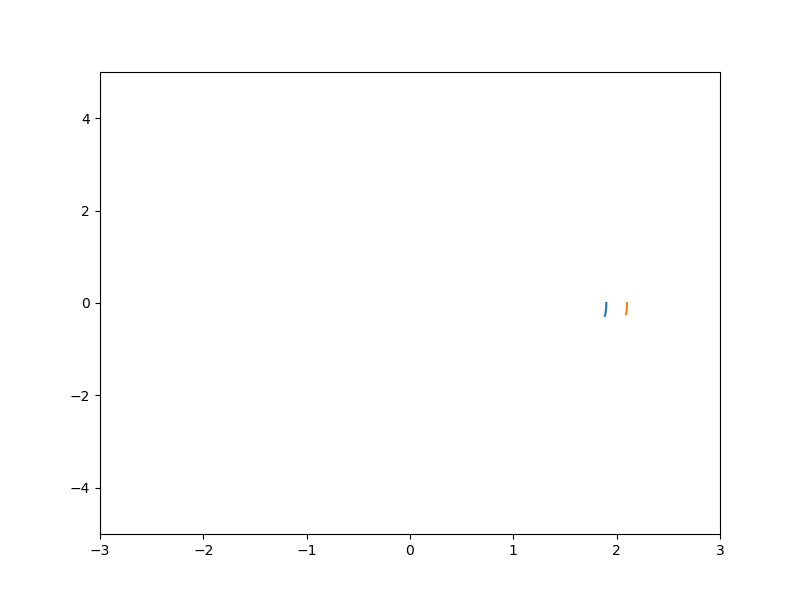

In [66]:
event = lambda t,y: y[1]
event.terminal = 2
event.direction = -1.

sols = []
for y0 in y0s:
    sols.append(solve_ivp(vanderpol,t_span,y0,dense_output=True,events=event,atol=1e-8,rtol=1e-8))
maxsteps = max([len(sol.t) for sol in sols])
print(maxsteps)

fig, ax = plt.subplots(figsize=(8,6))

lns = []
for sol in sols:
    ln, = ax.plot([], [])
    lns.append(ln)

def init():
    ax.set_xlim(a, b)
    ax.set_ylim(c, d)
    return lns[0],

def update(frame):
    for sol,ln in zip(sols,lns):
        ln.set_data(sol.y[0,:frame], sol.y[1,:frame])
    return lns[0],

ani = FuncAnimation(fig, update, frames=range(1,maxsteps+1),
                    init_func=init, blit=True)
plt.show()

In [81]:
y1,y2 = [sol for sol in sols]
t1,t2 = y1.t[-1],y2.t[-1]
z1 = CubicHermiteSpline(y1.t/y1.t[-1],y1.y,vanderpol(_,y1.y),axis=1)
z2 = CubicHermiteSpline(y2.t/y2.t[-1],y2.y,vanderpol(_,y2.y),axis=1)

In [67]:
def s1(t):
    

In [68]:
τ = np.linspace(0,1,1000)
z = np.array([z1(t) for t in τ]).T

In [69]:
z

array([[ 2.01418974e+00,  2.01402923e+00,  2.01377786e+00, ...,
         2.01424198e+00,  2.01426385e+00,  2.01418974e+00],
       [ 0.00000000e+00, -1.91329279e-02, -3.77885561e-02, ...,
         3.99163224e-02,  1.96640720e-02, -1.52655666e-16]],
      shape=(2, 1000))

In [70]:
zdiff = np.diff(z)
zdiff

array([[-1.60508706e-04, -2.51374759e-04, -3.39967361e-04, ...,
         1.20742049e-04,  2.18765328e-05, -7.41156678e-05],
       [-1.91329279e-02, -1.86556282e-02, -1.81895970e-02, ...,
        -2.08567201e-02, -2.02522504e-02, -1.96640720e-02]],
      shape=(2, 999))

In [71]:
znorm = np.array([[0,-1],[1,0]])@zdiff

<IPython.core.display.Javascript object>


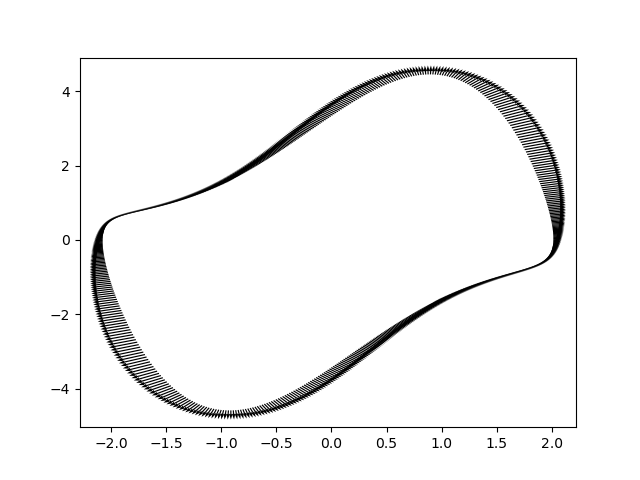

In [73]:
plt.quiver(z[0,:-1],z[1,:-1],znorm[0],znorm[1])

In [74]:
dots=(np.array(vanderpol(_,z[:,:-1]))*znorm).sum(axis=0)

<IPython.core.display.Javascript object>


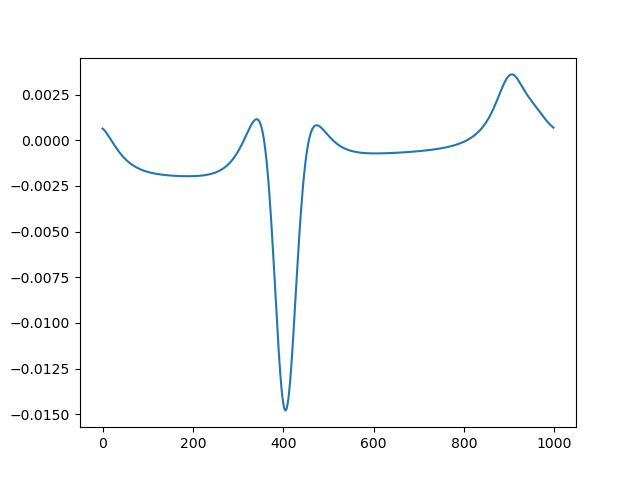

In [75]:
plt.plot(dots)